/tmp/ipykernel_18555/3411146946.py:117: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  % datetime.datetime.utcnow().strftime('%Y-%m-%d'))
INFO:__main__:Starting prediction on 2026-05-17 UTC time
INFO:__main__:Installing ColabFold on Google Colab virtual machine.


Installing ColabFold
Using Tesla T4 graphics processor
Prediction may fail with total sequence length over 1000 residues due to limited GPU memory.
Predicting 1025 residues.


2026-05-17 19:16:50,785 Running on GPU
2026-05-17 19:16:51,186 Found 5 citations for tools or databases
2026-05-17 19:16:51,186 Query 1/1: af1025 (length 1025)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]


2026-05-17 19:16:55,725 Setting max_seq=512, max_extra_seq=3780
2026-05-17 19:22:05,633 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=75.2 pTM=0.648
2026-05-17 19:26:36,821 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=76.4 pTM=0.67 tol=1.51
2026-05-17 19:30:48,346 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=76.8 pTM=0.63 tol=0.937
2026-05-17 19:35:00,008 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=77 pTM=0.625 tol=0.678
2026-05-17 19:35:00,015 alphafold2_ptm_model_1_seed_000 took 1063.7s (3 recycles)


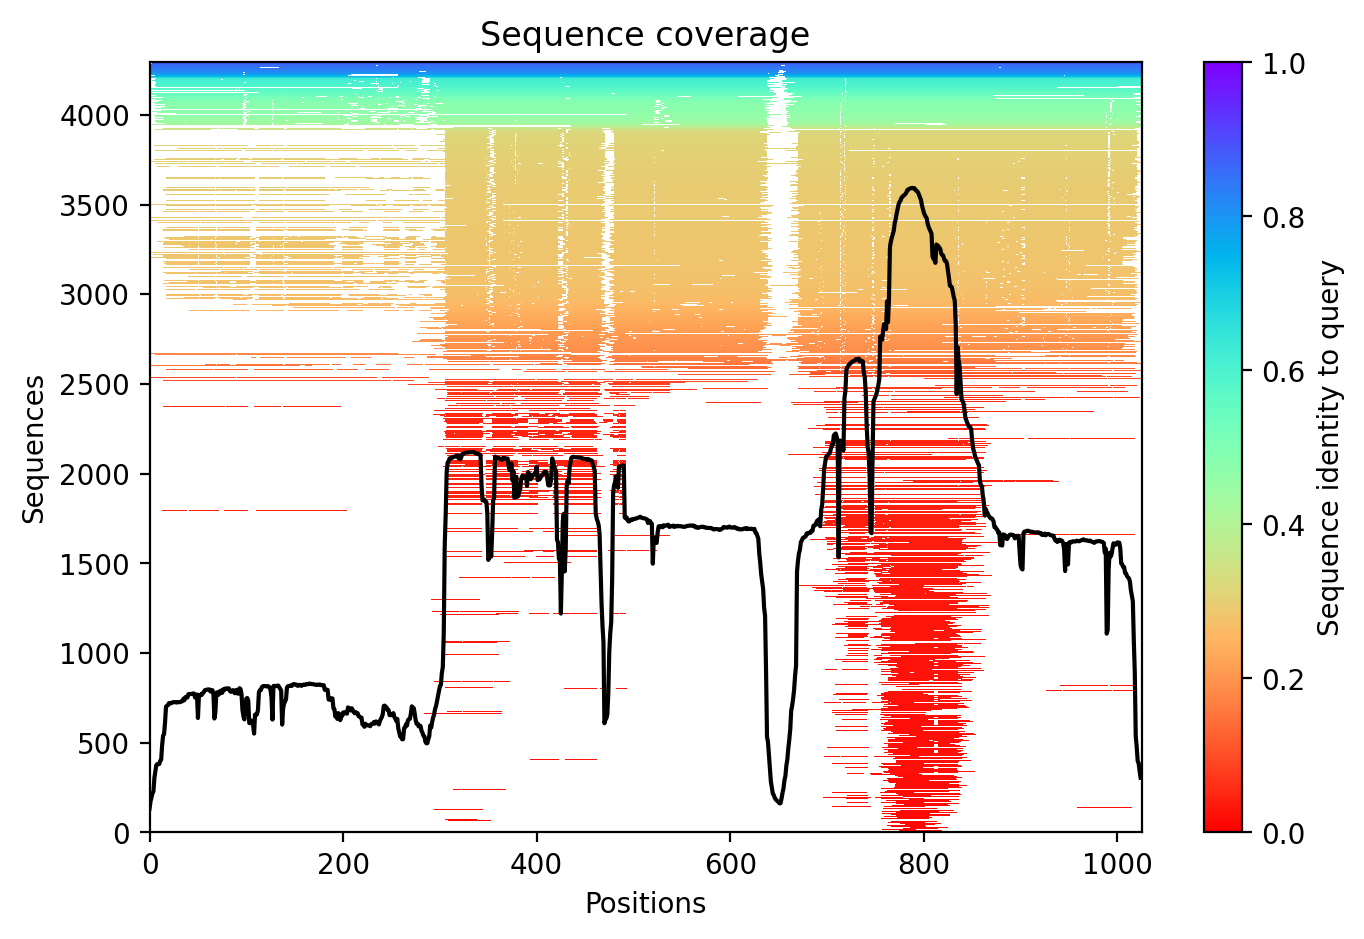

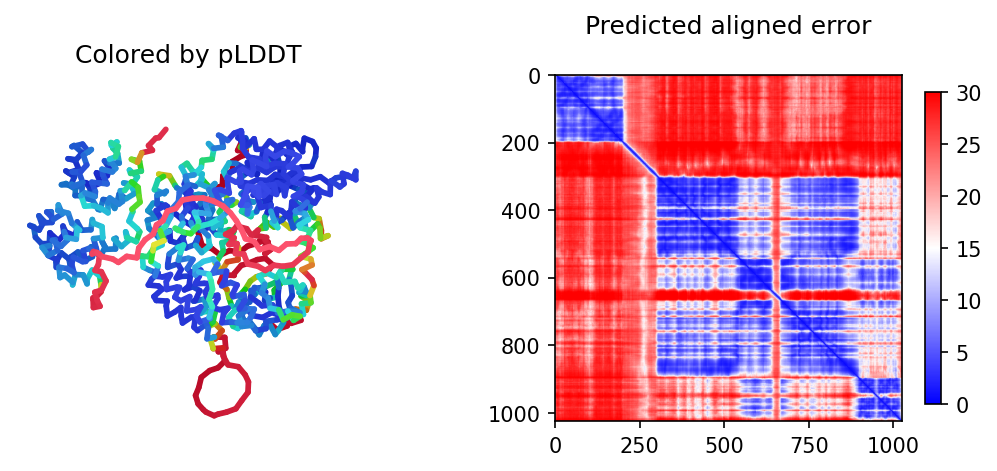

2026-05-17 19:39:12,773 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=75.8 pTM=0.647
2026-05-17 19:43:23,609 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=75.9 pTM=0.657 tol=2.59
2026-05-17 19:47:34,751 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=77 pTM=0.637 tol=1.25


In [ ]:
# ================================================================================================
# Google Colab code for running an AlphaFold structure prediction using ColabFold.
#
def run_prediction(sequences,
                   job_name = '',
                   msa_mode = "MMseqs2 (UniRef+Environmental)",
                   pair_mode = "unpaired+paired",
                   use_templates = False,
                   custom_template_path = None,
                   energy_minimize = False,
                   model_type = "auto",
                   num_recycles = 3,
                   dpi = 200,
                   install_log = 'install_log.txt'):
    '''
    Installs alphafold if not yet installed and runs a stucture prediction.
    Model names ending in "_ptm" predict TM score ('model_1_ptm', ..., 'model_5_ptm').

    Parameters
    ----------
    msa_mode: "MMseqs2 (UniRef+Environmental)", "MMseqs2 (UniRef only)", "single_sequence", "custom"
    pair_mode: "unpaired+paired", "paired", "unpaired"
       "unpaired+paired" = pair sequences from same species + unpaired MSA
       "unpaired" = seperate MSA for each chain
       "paired" - only use paired sequences.
    model_type: "auto", "AlphaFold2-ptm", "AlphaFold2-multimer-v1", "AlphaFold2-multimer-v2"
       "auto" = protein structure prediction using "AlphaFold2-ptm" and complex prediction "AlphaFold-multimer-v2"
        For complexes "AlphaFold-multimer-v[1,2]" and "AlphaFold-ptm" can be used.
    dpi: dots-per-inch for saved plot images
    '''

    start_logging()

    use_amber = energy_minimize

    install(use_amber=use_amber, use_templates=use_templates, install_log=install_log)

    report_gpu_type()

    warn_about_sequence_length(sequences)

    remove_old_files()

    if not job_name:
        nres = sum(len(seq) for seq in sequences)
        job_name = 'af%d' % nres

    # Write sequences, used only for inclusion in returned results.
    with open('query.fasta', 'w') as seqs_file:
        seqs_file.write(''.join(f'>{i+1}\n{seq}\n' for i,seq in enumerate(sequences)))

    from pathlib import Path
    from colabfold import utils
    if not hasattr(utils, 'setup_logging_done'):
        utils.setup_logging(Path(".").joinpath("log.txt"))
        utils.setup_logging_done = True

    # Avoid various FutureWarning message from deprecated jax features
    import warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)

    query_sequence = ':'.join(sequences)
    queries_path=f"{job_name}.csv"
    with open(queries_path, "w") as text_file:
      text_file.write(f"id,sequence\n{job_name},{query_sequence}")

    from colabfold.batch import get_queries, set_model_type
    queries, is_complex = get_queries(queries_path)
    model_type = set_model_type(is_complex, model_type)

    from colabfold.download import download_alphafold_params
    download_alphafold_params(model_type, Path("."))

    from colabfold.batch import run
    run(
      queries=queries,
      result_dir='.',
      use_templates=use_templates,
      custom_template_path=custom_template_path,
      use_amber=use_amber,
      msa_mode=msa_mode,
      model_type=model_type,
      num_models=5,
      num_recycles=num_recycles,
      model_order=[1, 2, 3, 4, 5],
      is_complex=is_complex,
      data_dir=Path("."),
      keep_existing_results=False,
      recompile_padding=1.0,
      rank_by="auto",
      pair_mode=pair_mode,
      stop_at_score=100.0,
      feature_dict_callback=plot_msa,
      prediction_callback=prediction_callback,
      dpi=dpi,
      user_agent='ChimeraX chimerax-programmers@cgl.ucsf.edu'
    )

    print('Downloading structure predictions to directory Downloads/ChimeraX/AlphaFold')
    download_results(energy_minimize)

# ================================================================================================
#
def start_logging():
    msg = 'Please cite <a href="https://www.nature.com/articles/s41592-022-01488-1">ColabFold: Making protein folding accessible to all. Nature Methods (2022)</a> if you use these predictions.'
    from IPython.display import display, HTML
    display(HTML(msg))

    # Change logging to not show milliseconds
    import logging
    logging.basicConfig(format='%(asctime)s %(message)s', datefmt='%-H:%M:%S')
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    import datetime
    logger.info('Starting prediction on %s UTC time'
                % datetime.datetime.utcnow().strftime('%Y-%m-%d'))

# ================================================================================================
#
def plot_msa(input_features, dpi=200):
    from colabfold.plot import plot_msa_v2
    plot_msa_v2(input_features, dpi=dpi)

# ================================================================================================
#
def prediction_callback(unrelaxed_protein, query_sequence_len_array,
                        prediction_result, input_features, type):
  import matplotlib.pyplot as plt
  multimer = (len(query_sequence_len_array) > 1)
  nplots = 3 if multimer else 2
  fig, axes = plt.subplots(1,nplots,figsize=(9,3), dpi=150)
  plot_protein(unrelaxed_protein, axes[0], coloring = 'plddt')
  from colabfold.colabfold import plot_pae
  plot_pae(prediction_result["predicted_aligned_error"], axes[1],
           Ls = query_sequence_len_array, colorkey_size = 0.9)
  axes[1].set_title("Predicted aligned error", pad=20)  # Add some padding to the caption.
  if multimer:
      plot_protein(unrelaxed_protein, axes[2], coloring = 'chain',
                   query_sequence_len_array=query_sequence_len_array)
  plt.show()
  plt.close()

# ================================================================================================
#
def plot_protein(protein, plot_axis, coloring='plddt', query_sequence_len_array = None,
                 best_view=True, line_w=2.0):
  import numpy as np
  pos = np.asarray(protein.atom_positions[:,1,:])
  plddt = np.asarray(protein.b_factors[:,0])

  from colabfold import colabfold
  colabfold.plot_protein_backbone(protein = protein, pos = pos, plddt = plddt,
                                  axes = plot_axis, coloring = coloring, Ls = query_sequence_len_array,
                                  best_view = best_view, line_w = line_w)

  if coloring == 'plddt':
    plot_axis.set_title('Colored by pLDDT')
  elif coloring == 'chain':
    plot_axis.set_title('Colored by chain')

# ================================================================================================
#
def download_results(energy_minimize):
  use_utf8_encoding()	# Work around preferred encoding bug.

  relax = 'relaxed' if energy_minimize else 'unrelaxed'
  !cp -p *_{relax}_rank_001_*.pdb best_model.pdb
  !cp -p *_scores_rank_001_*.json best_model_pae.json

  # Make a zip file of the predictions
  !zip -q -r results.zip query.fasta *.csv *.json *.a3m *.pdb cite.bibtex *.png *log.txt

  # Download predictions.
  from google.colab import files
  files.download('results.zip')

# ================================================================================================
#
def use_utf8_encoding():
  # Work-around bug where Conda/OpenMM changes the preferred encoding to ANSI breaking
  # Google Colab shell magic which requires UTF-8 encoding (January 17, 2023).
  # https://github.com/deepmind/alphafold/issues/483
  # https://www.rbvi.ucsf.edu/trac/ChimeraX/ticket/8313
  import locale
  if locale.getpreferredencoding() != 'UTF-8':
      locale.getpreferredencoding_orig = locale.getpreferredencoding
      def get_preferred_encoding_utf8(do_setlocale=True):
          return 'UTF-8'
      locale.getpreferredencoding = get_preferred_encoding_utf8

# ================================================================================================
#
def report_gpu_type():
  gpu_name_lines = !nvidia-smi --format=csv,noheader --query-gpu=name
  gpu_name = gpu_name_lines[0]
  print(f'Using {gpu_name} graphics processor')
  if gpu_name.startswith('Tesla K80'):
    if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
      import os
      del os.environ["TF_FORCE_UNIFIED_MEMORY"]
    if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
      import os
      del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

# ================================================================================================
#
def warn_about_sequence_length(sequences, warning_length = 1000):
    seq_len = sum([len(seq) for seq in sequences])
    if seq_len >= warning_length:
        print(f'Prediction may fail with total sequence length over {warning_length} residues due to limited GPU memory.\nPredicting {seq_len} residues.')

# ================================================================================================
#
def remove_old_files():
  '''
  Remove previous runs files otherwise they will not be overwritten because
  the file name contains both the rank number and model number.
  Also need to remove model_ and model_env directories otherwise errors
  occur if different sequences are run when computing MSA.
  '''
  !rm -rf *.pdb *.json *_ *_env *.zip *.csv *.png *.a3m *.fasta

# ================================================================================================
#
def install(use_amber = False, use_templates = False, install_log = 'install_log.txt'):

  from sys import version_info as vi
  python_version = f'{vi.major}.{vi.minor}'

  import logging
  logger = logging.getLogger(__name__)
  logger.info('Installing ColabFold on Google Colab virtual machine.')

  from os.path import exists
  if not exists('COLABFOLD_READY'):
    print ('Installing ColabFold')
    # If tensorflow is not imported then importing after install produces an error.  April 30, 2026
    # ChimeraX ticket #20256.
    import tensorflow
    cmds = f'''
set -e
# We have to use "--no-warn-conflicts" because colab already has a lot preinstalled with requirements different to ours
pip install --no-warn-conflicts "colabfold[alphafold-minus-jax]==1.6.1"
# We use the Google Colab system jaxlib since it needs to be compatible with CUDA.
# Haiku works with jax and we need an updated version to work with jax newer than 0.3.25.
pip install --upgrade dm-haiku
# patch for jax > 0.3.25
# sed -i 's/weights = jax.nn.softmax(logits)/logits=jnp.clip(logits,-1e8,1e8);weights=jax.nn.softmax(logits)/g' /usr/local/lib/python{python_version}/dist-packages/alphafold/model/modules.py
pip uninstall jax jaxlib -y
pip install "jax[cuda]==0.7.2" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
# Biopython 1.82 removes SCOPData required by AlphaFold.
# pip install biopython==1.81
# hack to fix Colab TensorFlow error Aug 14, 2025
# rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so
touch COLABFOLD_READY
'''
    run_shell_commands(cmds, 'install_colabfold.sh', install_log)

  if (use_amber or use_templates) and not exists('CONDA_READY'):
    print('Installing Conda')
    cmds = f'''
# setup conda
set -e
wget -qnc https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash Miniconda3-latest-Linux-x86_64.sh -bfp /usr/local 2>&1 1>/dev/null
rm Miniconda3-latest-Linux-x86_64.sh
touch CONDA_READY
'''
    run_shell_commands(cmds, 'install_conda.sh', install_log)

  if use_templates and not exists('HH_READY'):
    print('Installing hhsuite')
    cmds = f'''
# setup template search
set -e
# Avoid updating conda since it can break openmm install. ChimeraX bug #9265.
conda config --set auto_update_conda false
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
conda install -y -q -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python={python_version} 2>&1 1>/dev/null
touch HH_READY
'''
    run_shell_commands(cmds, 'install_hhsuite.sh', install_log)

  if use_amber and not exists('AMBER_READY'):
    print('Installing OpenMM')
    cmds = f'''
# setup openmm for amber refinement
set -e
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
conda install -y -q -c conda-forge openmm=8.2.0 python={python_version} pdbfixer 2>&1 1>/dev/null
# Make colab python find conda openmm and pdbfixer
ln -s /usr/local/lib/python{python_version}/site-packages/simtk .
ln -s /usr/local/lib/python{python_version}/site-packages/openmm .
ln -s /usr/local/lib/python{python_version}/site-packages/pdbfixer .
touch AMBER_READY
'''
    run_shell_commands(cmds, 'install_openmm.sh', install_log)

  # Enable colabfold logging from batch module.
  from colabfold.batch import logger as colabfold_logger
  import logging
  colabfold_logger.setLevel(logging.INFO)

# ================================================================================================
#
def run_shell_commands(commands, filename, install_log):
  with open(filename, 'w') as f:
    f.write(commands)

  # The -x option logs each command with a prompt in front of it.
  !bash -x "{filename}" >> "{install_log}" 2>&1
  if _exit_code != 0:
    raise RuntimeError('Error running shell script %s, output in log file %s'
                       % (filename, install_log))

# ================================================================================================
#
def remove_from_list(list, item):
  '''Remove an item from a list. Return true if removed otherwise false.'''
  try:
    list.remove(item)
    return True
  except ValueError:
    return False

# ================================================================================================
# Predict a structure for a sequence.
#
sequences = 'dont_minimize,MSNGYSTDENFRYLISCFRARVKMYIQVEPVLDYLTFLPAEVKEQIQRTVATSGNMQAVELLLSTLEKGVWHLGWTREFVEALRRTGSPLAARYMNPELTDLPSPSFENAHDEYLQLLNLLQPTLVDKLLVRDVLDKCMEEELLTIEDRNRIAAAENNGNESGVRELLKRIVQKENWFSAFLNVLRQTGNNELVQELTGSDCSESNAEIENLSQVDGPQVEEQLLSTTVQPNLEKEVWGMENNSSESSFADSSVVSESDTSLAEGSVSCLDESLGHNSNMGSDSGTMGSDSDEENVAARASPEPELQLRPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKRYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED'  #@param {type:"string"}

# Remove options from list of sequences
seq_list = [seq.strip() for seq in sequences.split(',')]
dont_minimize = remove_from_list(seq_list, 'dont_minimize')		# Energy minimization
use_templates = remove_from_list(seq_list, 'use_pdb_templates')
remove_from_list(seq_list, 'prokaryote')  # Obsolete "prokaryote" flag

run_prediction(seq_list, use_templates = use_templates, energy_minimize = not dont_minimize)
